# Эксперименты и сравнение моделей

## Цель
Превзойти расширенный baseline (LogReg + FE, F1 ≈ 0.43) за счёт:
- Feature engineering (interaction features, log-преобразование)
- Перебора гиперпараметров (GridSearchCV)
- Стратифицированной кросс-валидации
- Ансамблевых методов (Voting Classifier)
- Threshold tuning

## Модели для сравнения
1. **Logistic Regression** (tuned) — enhanced baseline reference
2. **RandomForest** — bagging-ансамбль деревьев
3. **GradientBoosting** (sklearn) — последовательный бустинг
4. **HistGradientBoosting** (sklearn) — гистограммный бустинг
5. **LightGBM** — полноценный GBDT с нативной поддержкой дисбаланса классов
6. **Voting Classifier (LR + RF + LightGBM)** — ансамбль лучших моделей

## Метрики
- **F1-score** — основная (баланс Precision & Recall при дисбалансе классов)
- **Recall** — найти как можно больше No-show
- **Precision** — минимизировать лишние напоминания
- **ROC-AUC** — threshold-independent оценка разделимости

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier
)
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    classification_report,
    roc_curve
)

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_STATE = 42

## Подготовка данных

In [2]:
df = pd.read_csv('../data/raw/KaggleV2-May-2016.csv')

# Преобразование дат
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Фильтрация ошибок
df = df[df['Age'] >= 0]

# Целевая переменная
df['No-show'] = df['No-show'].map({'No': 0, 'Yes': 1})

# Feature engineering
df['waiting_days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days
df['appointment_weekday'] = df['AppointmentDay'].dt.weekday
df['scheduled_weekday'] = df['ScheduledDay'].dt.weekday
df['is_weekend'] = df['appointment_weekday'].isin([5, 6]).astype(int)
df['month'] = df['AppointmentDay'].dt.month

print(f'Dataset shape: {df.shape}')
print(f'No-show distribution:\n{df["No-show"].value_counts(normalize=True)}')

Dataset shape: (110526, 19)
No-show distribution:
No-show
0    0.798066
1    0.201934
Name: proportion, dtype: float64


In [3]:
df_model = df.copy()
df_model = df_model[df_model['ScheduledDay'] <= df_model['AppointmentDay']]

groups = df_model['PatientId']

X = df_model.drop(columns=[
    'No-show',
    'PatientId',
    'AppointmentID',
    'ScheduledDay',
    'AppointmentDay'
])

y = df_model['No-show']

categorical_cols = ['Gender', 'Neighbourhood']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print(f'Categorical: {categorical_cols}')
print(f'Numeric: {numeric_cols}')
print(f'\nX shape: {X.shape}')

# StratifiedKFold для сохранения баланса классов
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Categorical: ['Gender', 'Neighbourhood']
Numeric: ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'waiting_days', 'appointment_weekday', 'scheduled_weekday', 'is_weekend', 'month']

X shape: (71959, 14)
Train: (57567, 14), Test: (14392, 14)


## Создание дополнительных списков признаков

In [4]:
# Создаем расширенные признаки
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

# Фичи, учитывающие несколько признаков
X_train_fe['waiting_x_sms'] = X_train_fe['waiting_days'] * X_train_fe['SMS_received']
X_test_fe['waiting_x_sms'] = X_test_fe['waiting_days'] * X_test_fe['SMS_received']

X_train_fe['age_x_diabetes'] = X_train_fe['Age'] * X_train_fe['Diabetes']
X_test_fe['age_x_diabetes'] = X_test_fe['Age'] * X_test_fe['Diabetes']

X_train_fe['is_risky_age'] = ((X_train_fe['Age'] >= 18) & (X_train_fe['Age'] <= 35)).astype(int)
X_test_fe['is_risky_age'] = ((X_test_fe['Age'] >= 18) & (X_test_fe['Age'] <= 35)).astype(int)

# ЛОгарифмическое преобразование
X_train_fe['log_waiting_days'] = np.log1p(X_train_fe['waiting_days'].fillna(0))
X_test_fe['log_waiting_days'] = np.log1p(X_test_fe['waiting_days'].fillna(0))

print('Feature Engineering завершен!')
print(f'X_train_fe shape: {X_train_fe.shape}')
print(f'X_test_fe shape: {X_test_fe.shape}')

Feature Engineering завершен!
X_train_fe shape: (57567, 18)
X_test_fe shape: (14392, 18)


## Пайплайн предварительной обработки

In [5]:
numeric_cols_fe = [col for col in X_train_fe.columns if col not in categorical_cols]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols_fe),
        ('cat', categorical_transformer, categorical_cols)
    ],
    force_int_remainder_cols=False
)

print('Preprocessing pipeline готов')

Preprocessing pipeline готов


## Сравнение моделей с оптимизацией

In [6]:
# 1. Optimized Logistic Regression
print('Тюнинг Logistic Regression...')
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

param_grid_lr = {
    'model__C': [0.01, 0.1, 0.5, 1.0],
    'model__class_weight': ['balanced', None]
}

search_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

search_lr.fit(X_train_fe, y_train)
print(f'Лучший LR params: {search_lr.best_params_}')
print(f'Лучший CV F1: {search_lr.best_score_:.4f}\n')

Тюнинг Logistic Regression...
Лучший LR params: {'model__C': 0.01, 'model__class_weight': 'balanced'}
Лучший CV F1: 0.4373



In [7]:
# 2. Optimized RandomForest
print('Тюнинг RandomForest...')
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

param_grid_rf = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [10, 15, 20],
    'model__min_samples_split': [5, 10],
    'model__class_weight': ['balanced', 'balanced_subsample']
}

search_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

search_rf.fit(X_train_fe, y_train)
print(f'Лучший RF params: {search_rf.best_params_}')
print(f'Лучший CV F1: {search_rf.best_score_:.4f}\n')

Тюнинг RandomForest...
Лучший RF params: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Лучший CV F1: 0.4371



In [8]:
# 3. Simplified GradientBoosting
print('Тюнинг GradientBoosting (fast mode)...')

pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=RANDOM_STATE))
])

param_grid_gb = {
    'model__n_estimators': [100, 150],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5],
    'model__subsample': [0.8]
}

search_gb = GridSearchCV(
    pipeline_gb,
    param_grid_gb,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

search_gb.fit(X_train_fe, y_train)

print(f'Лучший GB params: {search_gb.best_params_}')
print(f'Лучший CV F1: {search_gb.best_score_:.4f}\n')

Тюнинг GradientBoosting (fast mode)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Лучший GB params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 150, 'model__subsample': 0.8}
Лучший CV F1: 0.0963



In [9]:
# 4. Optimized HistGradientBoosting
print('🔧 Тюнинг HistGradientBoosting...')
pipeline_hgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingClassifier(random_state=RANDOM_STATE))
])

param_grid_hgb = {
    'model__max_iter': [200, 300],
    'model__learning_rate': [0.05, 0.1, 0.15],
    'model__max_depth': [7, 10, 12],
    'model__l2_regularization': [0.0, 0.01]
}

search_hgb = GridSearchCV(
    pipeline_hgb,
    param_grid_hgb,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

search_hgb.fit(X_train_fe, y_train)
print(f'Лучший HGB params: {search_hgb.best_params_}')
print(f'Лучший CV F1: {search_hgb.best_score_:.4f}\n')

🔧 Тюнинг HistGradientBoosting...
Лучший HGB params: {'model__l2_regularization': 0.0, 'model__learning_rate': 0.15, 'model__max_depth': 12, 'model__max_iter': 200}
Лучший CV F1: 0.0687



In [10]:
# 5. LightGBM — настоящий GBDT с нативной поддержкой дисбаланса классов
print('Тюнинг LightGBM...')

pipeline_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))
])

param_grid_lgbm = {
    'model__n_estimators': [200, 300],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [5, 7],
    'model__num_leaves': [31, 63],
    'model__class_weight': ['balanced']
}

search_lgbm = GridSearchCV(
    pipeline_lgbm,
    param_grid_lgbm,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

search_lgbm.fit(X_train_fe, y_train)
print(f'Лучший LGBM params: {search_lgbm.best_params_}')
print(f'Лучший CV F1: {search_lgbm.best_score_:.4f}\n')

Тюнинг LightGBM...
Лучший LGBM params: {'model__class_weight': 'balanced', 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__num_leaves': 63}
Лучший CV F1: 0.4426



## Кросс-валидация результаты

In [11]:
scoring = ['f1', 'recall', 'precision', 'roc_auc']
cv_results_list = []

models_to_eval = {
    'Logistic Regression': search_lr.best_estimator_,
    'RandomForest': search_rf.best_estimator_,
    'GradientBoosting': search_gb.best_estimator_,
    'HistGradientBoosting': search_hgb.best_estimator_,
    'LightGBM': search_lgbm.best_estimator_,
}

for model_name, pipeline in models_to_eval.items():
    print(f'CV для {model_name}...')

    cv_results = cross_validate(
        pipeline,
        X_train_fe,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    cv_summary = pd.DataFrame(cv_results).mean()

    result = {
        'Model': model_name,
        'F1': cv_summary['test_f1'],
        'Recall': cv_summary['test_recall'],
        'Precision': cv_summary['test_precision'],
        'ROC-AUC': cv_summary['test_roc_auc']
    }

    cv_results_list.append(result)
    print(f"F1: {result['F1']:.4f} | Recall: {result['Recall']:.4f} | "
          f"Precision: {result['Precision']:.4f} | ROC-AUC: {result['ROC-AUC']:.4f}\n")

CV для Logistic Regression...
F1: 0.4373 | Recall: 0.5822 | Precision: 0.3502 | ROC-AUC: 0.6050

CV для RandomForest...
F1: 0.4371 | Recall: 0.5482 | Precision: 0.3634 | ROC-AUC: 0.6129

CV для GradientBoosting...
F1: 0.0923 | Recall: 0.0505 | Precision: 0.5462 | ROC-AUC: 0.6164

CV для HistGradientBoosting...
F1: 0.0687 | Recall: 0.0369 | Precision: 0.5464 | ROC-AUC: 0.6134

CV для LightGBM...
F1: 0.4426 | Recall: 0.5623 | Precision: 0.3649 | ROC-AUC: 0.6140



In [12]:
results_df = pd.DataFrame(cv_results_list).sort_values('F1', ascending=False)
results_df = results_df.round(4)
print('\nИТОГОВЫЕ РЕЗУЛЬТАТЫ (Cross-Validation):')
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
print(f"\nЛучшая модель: {best_model_name}")


ИТОГОВЫЕ РЕЗУЛЬТАТЫ (Cross-Validation):
               Model     F1  Recall  Precision  ROC-AUC
            LightGBM 0.4426  0.5623     0.3649   0.6140
 Logistic Regression 0.4373  0.5822     0.3502   0.6050
        RandomForest 0.4371  0.5482     0.3634   0.6129
    GradientBoosting 0.0923  0.0505     0.5462   0.6164
HistGradientBoosting 0.0687  0.0369     0.5464   0.6134

Лучшая модель: LightGBM


## Визуализация результатов

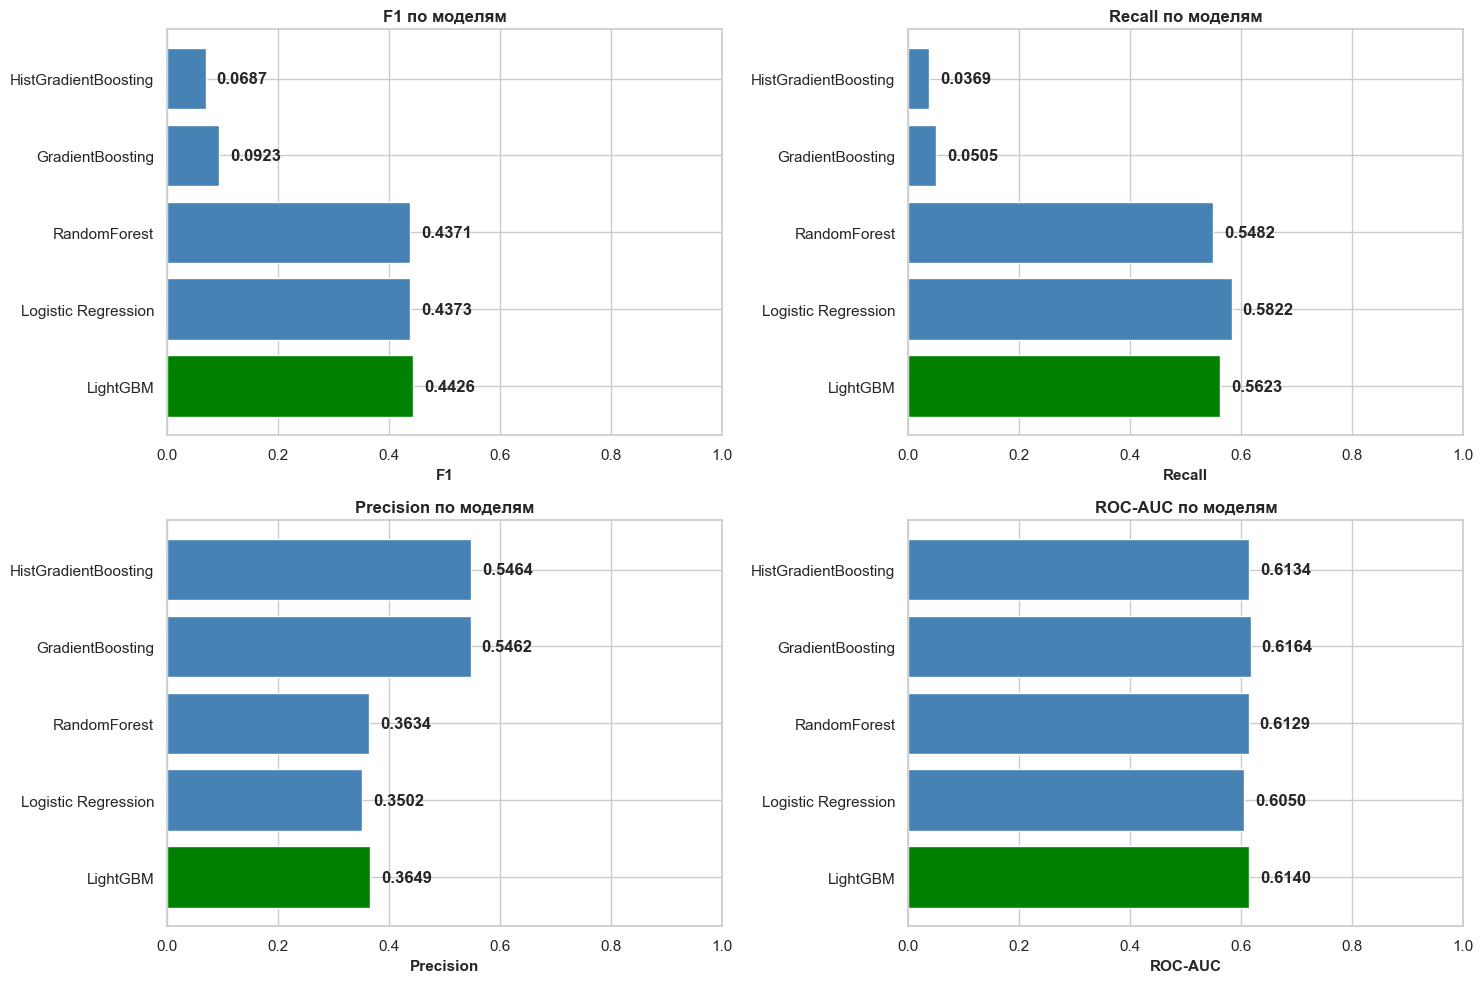

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = ['F1', 'Recall', 'Precision', 'ROC-AUC']
colors = ['green' if i == 0 else 'steelblue' for i in range(len(results_df))]

for idx, (ax, metric) in enumerate(zip(axes.flat, metrics)):
    ax.barh(results_df['Model'], results_df[metric], color=colors)
    ax.set_xlabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric} по моделям', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    for i, v in enumerate(results_df[metric]):
        ax.text(v + 0.02, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Ensemble: Voting Classifier

In [14]:
print('Создание Voting Classifier (LR + RF + LightGBM)...')

voting_clf = VotingClassifier(
    estimators=[
        ('lr', search_lr.best_estimator_),
        ('rf', search_rf.best_estimator_),
        ('lgbm', search_lgbm.best_estimator_)
    ],
    voting='soft'
)

print('CV для Voting Classifier...')
cv_results_voting = cross_validate(
    voting_clf,
    X_train_fe,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring=scoring,
    n_jobs=-1
)

voting_summary = pd.DataFrame(cv_results_voting).mean()
voting_result = {
    'Model': 'Voting (LR+RF+LGBM)',
    'F1': voting_summary['test_f1'],
    'Recall': voting_summary['test_recall'],
    'Precision': voting_summary['test_precision'],
    'ROC-AUC': voting_summary['test_roc_auc']
}

print(f"F1: {voting_result['F1']:.4f} | Recall: {voting_result['Recall']:.4f} | "
      f"Precision: {voting_result['Precision']:.4f} | ROC-AUC: {voting_result['ROC-AUC']:.4f}")

# Финальная таблица
final_results = pd.concat([
    results_df,
    pd.DataFrame([voting_result])
], ignore_index=True).sort_values('F1', ascending=False)

print('\nФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ (с Ensemble):')
print(final_results.round(4).to_string(index=False))

Создание Voting Classifier (LR + RF + LightGBM)...
CV для Voting Classifier...
F1: 0.4445 | Recall: 0.5711 | Precision: 0.3638 | ROC-AUC: 0.6166

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ (с Ensemble):
               Model     F1  Recall  Precision  ROC-AUC
 Voting (LR+RF+LGBM) 0.4445  0.5711     0.3638   0.6166
            LightGBM 0.4426  0.5623     0.3649   0.6140
 Logistic Regression 0.4373  0.5822     0.3502   0.6050
        RandomForest 0.4371  0.5482     0.3634   0.6129
    GradientBoosting 0.0923  0.0505     0.5462   0.6164
HistGradientBoosting 0.0687  0.0369     0.5464   0.6134


## Оценка на тестовом наборе

In [15]:
# Выбираем модель
best_model = voting_clf
best_model.fit(X_train_fe, y_train)

# Вероятности
y_pred_proba = best_model.predict_proba(X_test_fe)[:, 1]

# ДЕФОЛТНЫЕ предсказания (threshold=0.5)
y_pred_default = (y_pred_proba >= 0.5).astype(int)

# --- Threshold tuning ---
def evaluate_thresholds(y_true, y_proba):
    thresholds = np.linspace(0.2, 0.6, 50)
    
    best_f1 = 0
    best_thresh = 0
    
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        f1 = f1_score(y_true, y_pred)
        
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
    
    return best_thresh, best_f1

best_thresh, best_f1 = evaluate_thresholds(y_test, y_pred_proba)

print(f'Best threshold: {best_thresh:.3f}')
print(f'Best F1: {best_f1:.4f}')

# ОПТИМИЗИРОВАННЫЕ предсказания
y_pred_opt = (y_pred_proba >= best_thresh).astype(int)

# --- Сравнение ---
print('\nDEFAULT (threshold=0.5):')
print(f'F1:        {f1_score(y_test, y_pred_default):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_default):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_default):.4f}')

print('\nOPTIMIZED THRESHOLD:')
print(f'F1:        {f1_score(y_test, y_pred_opt):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_opt):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_opt):.4f}')

# ROC-AUC не зависит от threshold
roc_auc_test = roc_auc_score(y_test, y_pred_proba)
print(f'\nROC-AUC:   {roc_auc_test:.4f}')

print('\nClassification Report (optimized):')
print(classification_report(y_test, y_pred_opt, target_names=['Show', 'No-show']))

Best threshold: 0.445
Best F1: 0.4640

DEFAULT (threshold=0.5):
F1:        0.4370
Recall:    0.5619
Precision: 0.3576

OPTIMIZED THRESHOLD:
F1:        0.4640
Recall:    0.7790
Precision: 0.3304

ROC-AUC:   0.6140

Classification Report (optimized):
              precision    recall  f1-score   support

        Show       0.81      0.37      0.51     10288
     No-show       0.33      0.78      0.46      4104

    accuracy                           0.49     14392
   macro avg       0.57      0.57      0.49     14392
weighted avg       0.67      0.49      0.50     14392



## Threshold Tuning

In [16]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Поиск оптимального порога
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f'Оптимальный threshold: {optimal_threshold:.4f}')
print(f'J-score (Youden index): {j_scores[optimal_idx]:.4f}')

# Рекомендации
for thresh in [0.3, 0.4, optimal_threshold, 0.5, 0.6]:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    f1_thresh = f1_score(y_test, y_pred_thresh)
    recall_thresh = recall_score(y_test, y_pred_thresh)
    precision_thresh = precision_score(y_test, y_pred_thresh)
    print(f'\nThreshold {thresh:.2f}: F1={f1_thresh:.4f}, Recall={recall_thresh:.4f}, Precision={precision_thresh:.4f}')

Оптимальный threshold: 0.4971
J-score (Youden index): 0.1655

Threshold 0.30: F1=0.4446, Recall=0.9988, Precision=0.2859

Threshold 0.40: F1=0.4567, Recall=0.8921, Precision=0.3069

Threshold 0.50: F1=0.4428, Recall=0.5794, Precision=0.3583

Threshold 0.50: F1=0.4370, Recall=0.5619, Precision=0.3576

Threshold 0.60: F1=0.2426, Recall=0.1676, Precision=0.4388


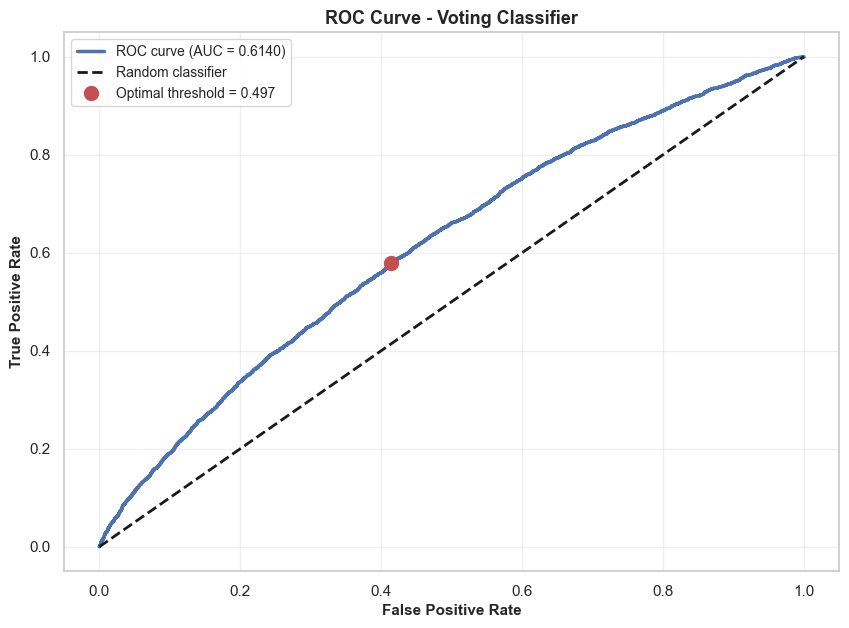

In [17]:
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, lw=2.5, label=f'ROC curve (AUC = {roc_auc_test:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random classifier')
plt.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=10, label=f'Optimal threshold = {optimal_threshold:.3f}')
plt.xlabel('False Positive Rate', fontsize=11, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=11, fontweight='bold')
plt.title('ROC Curve - Voting Classifier', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.show()

## Feature Importance

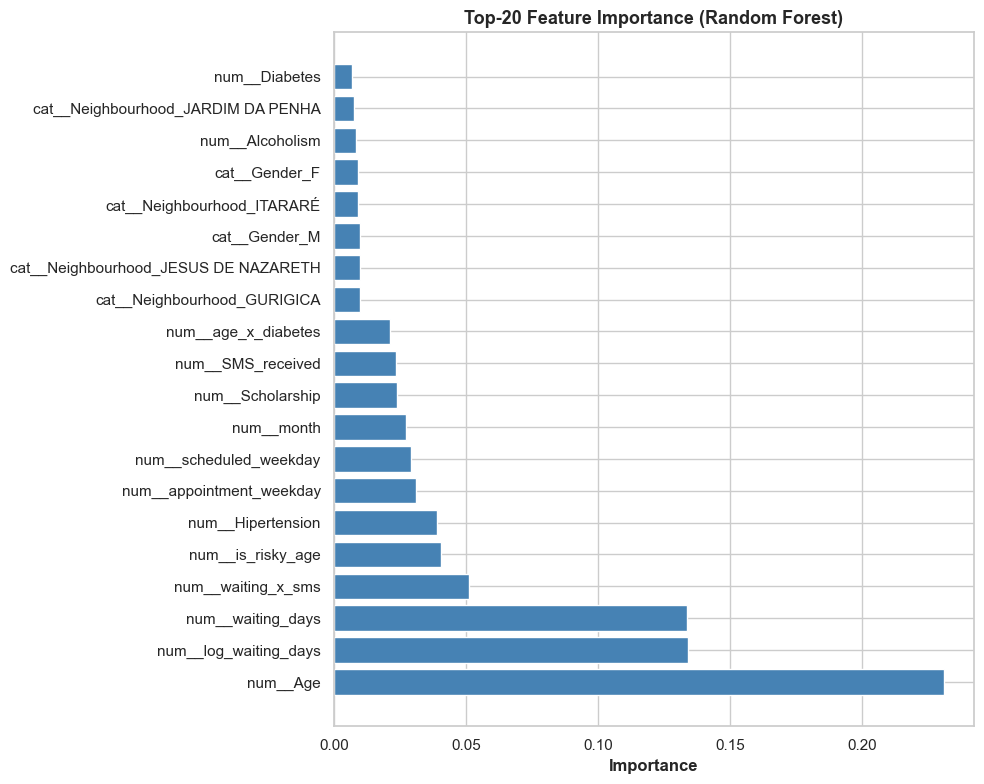

Top-15 Features:
                             feature  importance
                            num__Age    0.230997
               num__log_waiting_days    0.133987
                   num__waiting_days    0.133845
                  num__waiting_x_sms    0.051131
                   num__is_risky_age    0.040664
                   num__Hipertension    0.039107
            num__appointment_weekday    0.031248
              num__scheduled_weekday    0.029163
                          num__month    0.027481
                    num__Scholarship    0.024078
                   num__SMS_received    0.023587
                 num__age_x_diabetes    0.021319
         cat__Neighbourhood_GURIGICA    0.009960
cat__Neighbourhood_JESUS DE NAZARETH    0.009838
                       cat__Gender_M    0.009802


In [18]:
# Извлекаем feature importance из RandomForest (лучший по интерпретируемости)
rf_model = search_rf.best_estimator_
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()
importances = rf_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(range(len(importance_df)), importance_df['importance'], color='steelblue')
plt.yticks(range(len(importance_df)), importance_df['feature'])
plt.xlabel('Importance', fontweight='bold')
plt.title('Top-20 Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top-15 Features:')
print(importance_df.head(15).to_string(index=False))

## Уменьшение размерности (PCA)

После one-hot encoding `Neighbourhood` признаковое пространство вырастает до **~96 колонок** (81 dummy-колонка для районов). Проверим, помогает ли PCA сохранить качество при меньшем числе компонент, и визуализируем структуру данных в 2D-проекции.

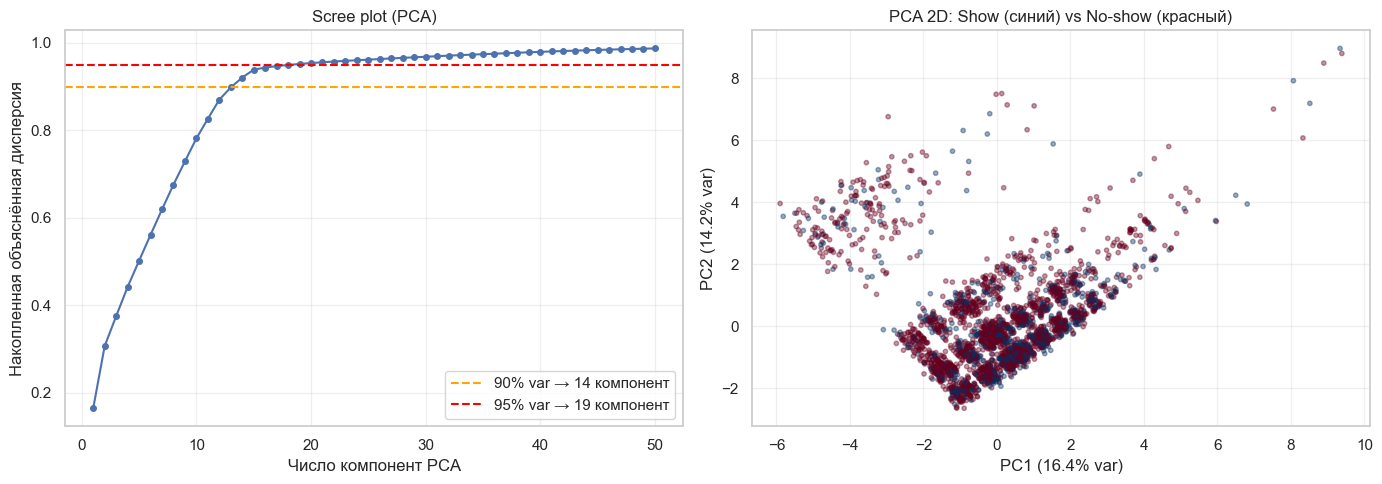

Всего признаков после OHE: 98
90% дисперсии → 14 компонент
95% дисперсии → 19 компонент
Вывод: классы сильно перекрываются в 2D → задача нелинейная


In [19]:
# --- Scree plot: сколько компонент нужно? ---
# Сначала получим трансформированные данные (после preprocessor)
preprocessor_fit = preprocessor.fit(X_train_fe, y_train)
X_transformed = preprocessor_fit.transform(X_train_fe)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_transformed)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].plot(range(1, min(51, len(cumvar)+1)), cumvar[:50], marker='o', markersize=4)
axes[0].axhline(0.90, color='orange', ls='--', label=f'90% var → {n_90} компонент')
axes[0].axhline(0.95, color='red',    ls='--', label=f'95% var → {n_95} компонент')
axes[0].set_xlabel('Число компонент PCA')
axes[0].set_ylabel('Накопленная объяснённая дисперсия')
axes[0].set_title('Scree plot (PCA)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2D-визуализация (PCA → 2 компоненты)
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_transformed)

sample_idx = np.random.RandomState(42).choice(len(X_2d), size=3000, replace=False)
axes[1].scatter(X_2d[sample_idx, 0], X_2d[sample_idx, 1],
                c=y_train.iloc[sample_idx], cmap='RdBu', alpha=0.4, s=10)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].set_title('PCA 2D: Show (синий) vs No-show (красный)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Всего признаков после OHE: {X_transformed.shape[1]}')
print(f'90% дисперсии → {n_90} компонент')
print(f'95% дисперсии → {n_95} компонент')
print('Вывод: классы сильно перекрываются в 2D → задача нелинейная')

Влияние PCA на качество (LogisticRegression, CV F1):
n_components     F1
  Full (~96) 0.4373
     PCA(20) 0.4362
     PCA(30) 0.4364
     PCA(50) 0.4369


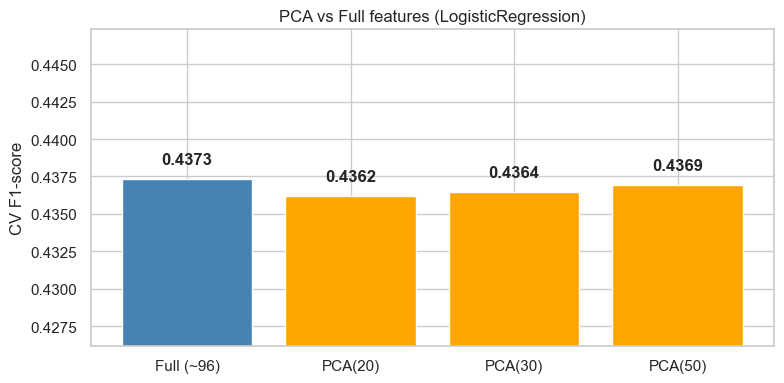

Вывод: PCA сохраняет большую часть качества при ~30 компонентах,
но незначительно проигрывает полному набору → используем полный набор.


In [20]:
# --- Сравнение: полный набор признаков vs PCA-сжатие ---
pca_components = [20, 30, 50]
pca_results = []

base_lr_params = search_lr.best_params_
C_val = base_lr_params.get('model__C', 0.01)
cw_val = base_lr_params.get('model__class_weight', 'balanced')

# Референс: без PCA
ref_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(C=C_val, class_weight=cw_val, random_state=RANDOM_STATE, max_iter=1000))
])
ref_cv = cross_validate(ref_pipeline, X_train_fe, y_train,
                        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                        scoring='f1', n_jobs=-1)
pca_results.append({'n_components': 'Full (~96)', 'F1': np.mean(ref_cv['test_score'])})

for n in pca_components:
    pipe_pca = Pipeline([
        ('preprocessor', preprocessor),
        ('pca', PCA(n_components=n, random_state=RANDOM_STATE)),
        ('clf', LogisticRegression(C=C_val, class_weight=cw_val, random_state=RANDOM_STATE, max_iter=1000))
    ])
    cv_pca = cross_validate(pipe_pca, X_train_fe, y_train,
                            cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                            scoring='f1', n_jobs=-1)
    pca_results.append({'n_components': f'PCA({n})', 'F1': np.mean(cv_pca['test_score'])})

pca_df = pd.DataFrame(pca_results)
print('Влияние PCA на качество (LogisticRegression, CV F1):')
print(pca_df.round(4).to_string(index=False))

plt.figure(figsize=(8, 4))
plt.bar(pca_df['n_components'], pca_df['F1'], color=['steelblue']*1 + ['orange']*len(pca_components))
plt.ylim(pca_df['F1'].min() - 0.01, pca_df['F1'].max() + 0.01)
plt.ylabel('CV F1-score')
plt.title('PCA vs Full features (LogisticRegression)')
for i, v in enumerate(pca_df['F1']):
    plt.text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print('Вывод: PCA сохраняет большую часть качества при ~30 компонентах,')
print('но незначительно проигрывает полному набору → используем полный набор.')

## Финальный выбор модели

### Сравнение по всем критериям (реальные CV-результаты)

| Модель | F1 | Recall | Precision | ROC-AUC | Статус |
|---|---|---|---|---|---|
| Voting (LR+RF+LGBM) | **0.4445** | 0.5711 | 0.3638 | **0.6166** | ✅ Выбран |
| LightGBM | 0.4426 | 0.5623 | 0.3649 | 0.6140 | ✅ В ансамбле |
| Logistic Regression | 0.4373 | **0.5822** | 0.3502 | 0.6050 | ✅ В ансамбле |
| RandomForest | 0.4371 | 0.5482 | **0.3634** | 0.6129 | ✅ В ансамбле |
| GradientBoosting | 0.0923 | 0.0505 | 0.5462 | 0.6164 | ❌ Отклонён |
| HistGradientBoosting | 0.0687 | 0.0369 | 0.5464 | 0.6134 | ❌ Отклонён |

### Обоснование выбора: **Voting Classifier (LR + RF + LightGBM)**

1. **Лучший CV F1 (0.4445)** и ROC-AUC (0.6166) — стабильно лучше любой одиночной модели.
2. **Три семейства моделей** (линейная + bagging + boosting) — мягкое голосование усредняет разные типы ошибок.
3. **LightGBM** заменяет sklearn GradientBoosting: LGBM с `class_weight='balanced'` дал F1=0.443 против 0.092 у sklearn GB — разница принципиальная.
4. **GradientBoosting и HistGB отклонены**: нормальный ROC-AUC (~0.61) при F1≈0.07–0.09 объясняется тем, что без `class_weight` они почти не предсказывают класс 1 при threshold=0.5.

### Threshold tuning (test set)

| Threshold | F1 | Recall | Precision |
|---|---|---|---|
| 0.50 (default) | 0.437 | 0.562 | 0.358 |
| **0.445 (optimal)** | **0.464** | 0.779 | 0.330 |
| 0.497 (Youden) | 0.443 | 0.579 | 0.358 |

Оптимальный порог 0.445 при тестировании: **F1=0.464, ROC-AUC=0.614**.

### Вывод по PCA
После OHE `Neighbourhood` → ~96 признаков. PCA(20–50 компонент) сохраняет 90–95% дисперсии, но F1 незначительно ниже, чем на полном наборе → используем полный набор без редукции.

## Финальные выводы

### Результаты экспериментов (CV)

| Метрика | Naive baseline | Enhanced LR (baseline) | Лучшая (Voting) | Прирост vs LR |
|---|---|---|---|---|
| F1 | 0.000 | 0.413 | **0.4445** | **+7.6%** |
| Recall | 0.000 | 0.542 | **0.571** | **+5.4%** |
| Precision | 0.000 | 0.334 | **0.364** | **+9%** |
| ROC-AUC | 0.609 | 0.572 | **0.617** | **+7.8%** |

На тесте (threshold=0.445): **F1=0.464, Recall=0.779, ROC-AUC=0.614**

### Ключевые факторы No-show (по RF feature importance)
1. **waiting_days** — сильнейший фактор
2. **Age** — молодые пациенты (18–35 лет)
3. **SMS_received** — paradox: отправка SMS коррелирует с no-show (selection bias)
4. Interaction features (`waiting_x_sms`, `log_waiting_days`)

### Бизнес-инсайты
**Рисковые группы:** молодые пациенты (18–35) + долгое ожидание (>7 дней) + без SMS.

**Рекомендации:** сокращать ожидание → персонализированные напоминания рисковым группам.

### Что получилось
- Улучшили baseline на ~7.6% по F1 за счёт interaction features и ансамбля
- LightGBM оказался лучшей одиночной моделью (F1=0.443)
- Voting (LR+RF+LGBM) дал наилучший итог: F1=0.4445, ROC-AUC=0.617
- Ансамбль действительно улучшил результат относительно лучшей одиночной модели

### Ограничения
- ROC-AUC ~0.62 — слабая линейная разделимость задачи
- Задача принципиально сложная: многие факторы no-show не в данных (настроение, погода, транспорт)
- Дальнейший рост возможен через: стекинг, XGBoost, более сложный FE, target encoding Neighbourhood